# Evaluating Real World Data

**Context:** Because of the very specific use case and the resulting requirements for the data, the models are trained on synthetic data. In this notebook, another dataset is evaluated to look into the applicability of real world data.

**Data Source:** https://zenodo.org/records/3828468

**Prerequisites/Prior Steps:**
- Data downloaded from source
- Data extracted from raw-files (images, audio, etc.)
- Data enrichened with target variable (synthetically computed)

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Import data from GCS

In [31]:
data = pd.read_csv("gs://aura_datasets_training_validation/new_dataset_with_target.csv")
data.head()

,id,audio_rms,audio_db,noise_db,people_count,mat_key,map_shape,crowd_db,lux_proxy,lux_db,discomfort_level
0,0007,0.097441,-20.225206,79.549587,90.0,map,"(1080, 1920)",19,114.457289,605.374801,0.762933
1,0010,0.099746,-20.022128,79.955745,92.0,map,"(1080, 1920)",17,112.567882,596.353885,0.742524
2,0011,0.100542,-19.953009,80.093982,118.0,map,"(1080, 1920)",17,113.409957,600.374346,0.744157
3,0014,0.099514,-20.042309,79.915382,104.0,map,"(1080, 1920)",18,104.967574,560.066461,0.743268
4,0024,0.105333,-19.548689,80.902622,97.0,map,"(1080, 1920)",13,106.737118,568.515092,0.699868


## Drop irrelevant columns

In [32]:
data = data[["noise_db", "crowd_db", "lux_db", "discomfort_level"]]

## Data Overview

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1934 entries, 0 to 1933
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   noise_db          1934 non-null   float64
 1   crowd_db          1934 non-null   int64  
 2   lux_db            1934 non-null   float64
 3   discomfort_level  1934 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 60.6 KB


In [34]:
data.describe()

,noise_db,crowd_db,lux_db,discomfort_level
count,1934.000000,1934.000000,1934.000000,1934.000000
mean,75.896820,13.863495,462.958809,0.643729
std,9.265367,5.949953,187.548099,0.112384
min,44.654181,0.000000,121.738624,0.342704
25%,71.280913,10.000000,312.218997,0.562027
50%,79.154999,14.000000,503.105381,0.657663
75%,82.846350,18.000000,576.516842,0.724389
max,89.540997,32.000000,1180.368054,0.989298


**Conclusion:**
- No missing values
- All relevant variables are numerical
- Ranges:
  - noise_db: 44 - 89 db
  - crowd_db: 0 - 32 people
  - lux_db: 121 - 1180 lux

Next step: Checking distribution of each variable to make sure they are representative.

## EDA

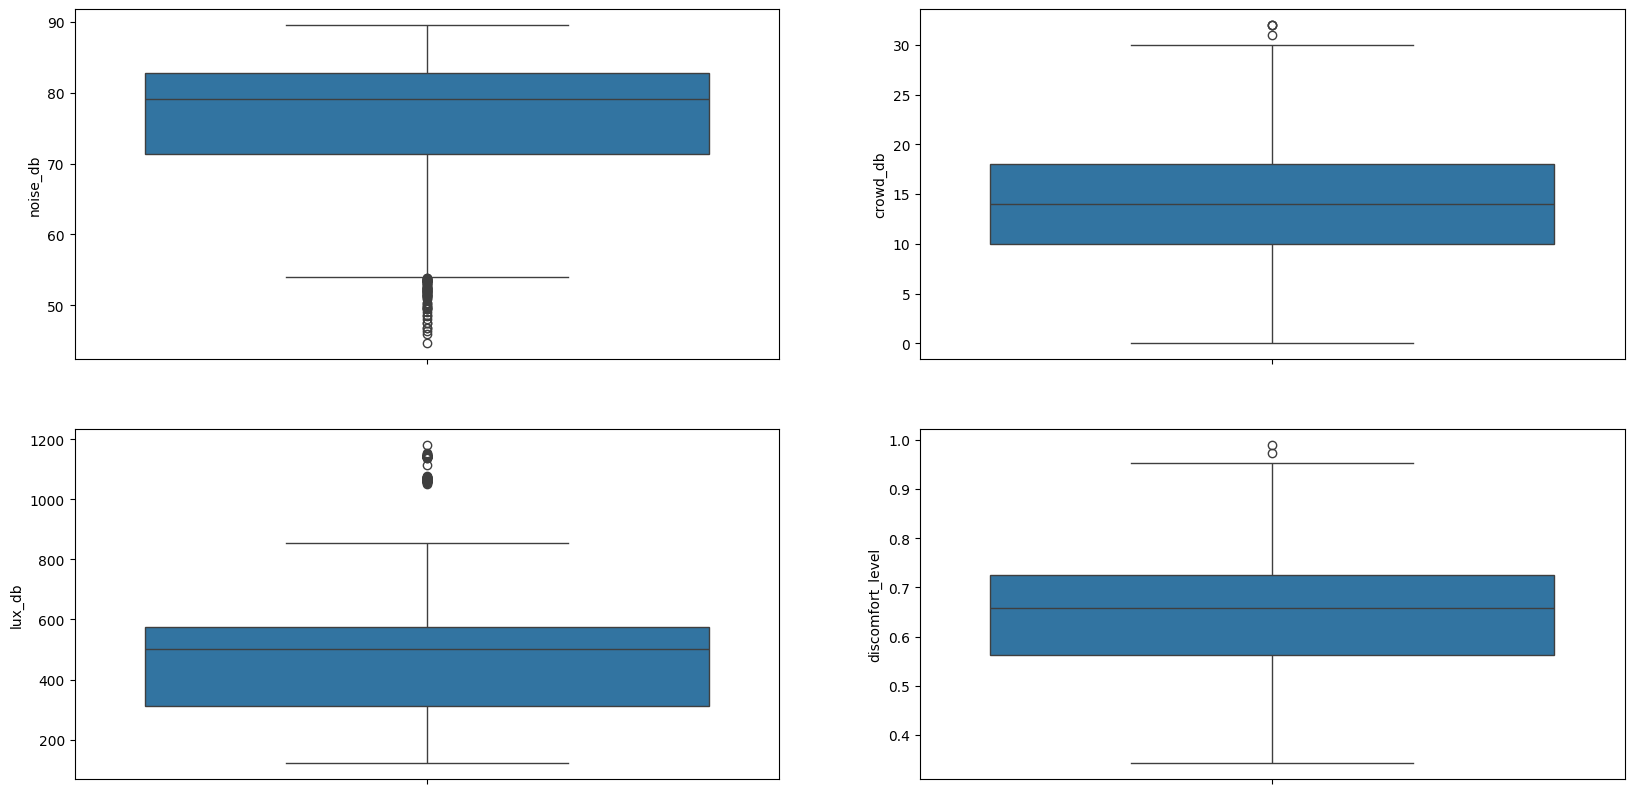

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(20,10))
for i, col in enumerate(data.columns):
    sns.boxplot(y=data[col], ax=axs.flatten()[i])

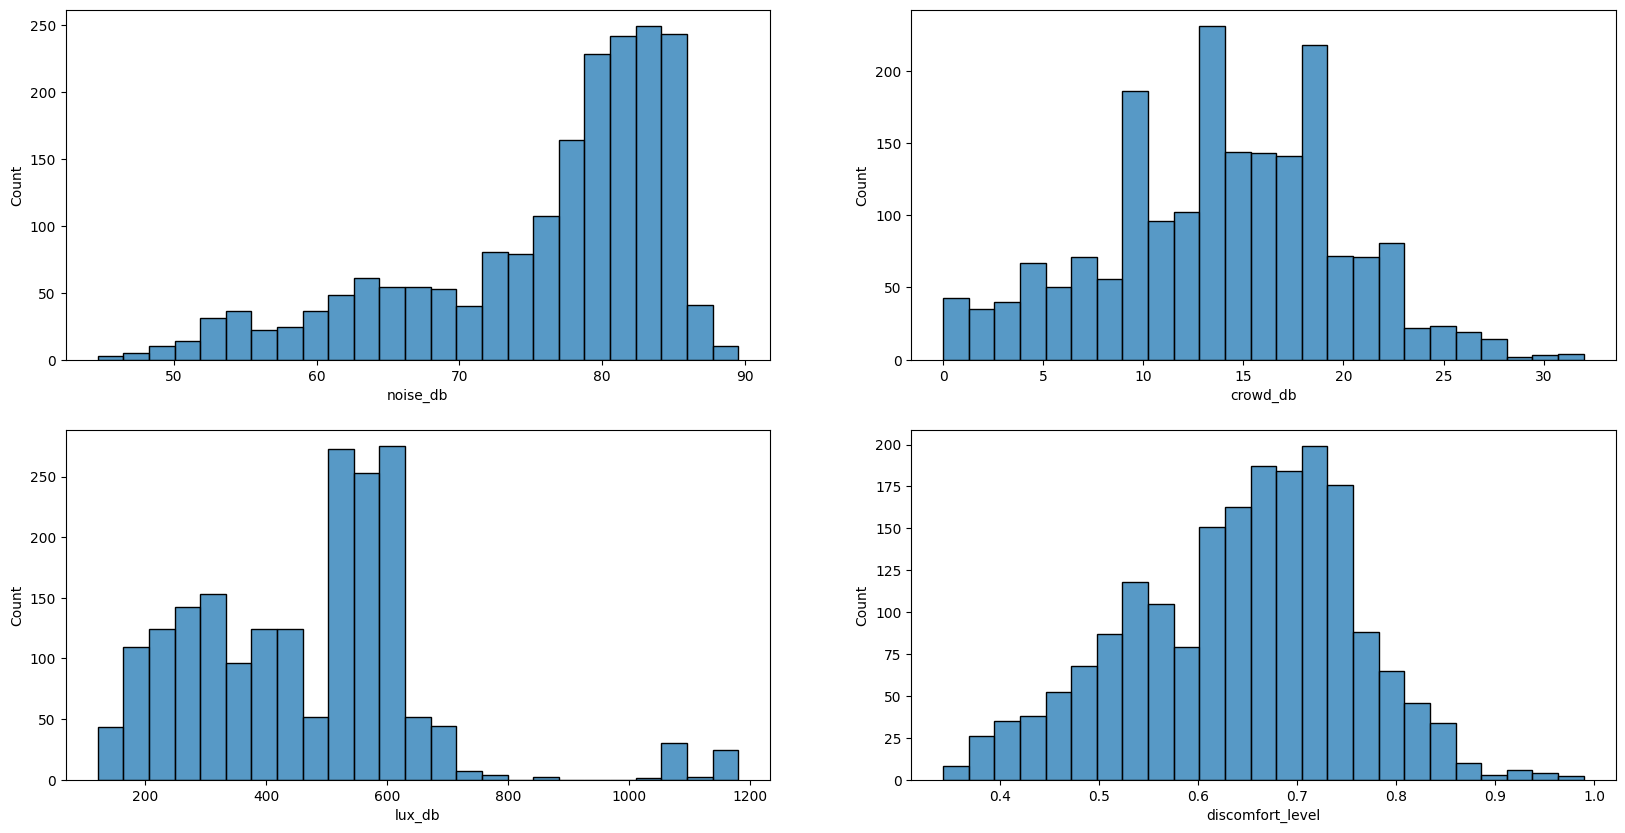

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(20,10))
for i, col in enumerate(data.columns):
    sns.histplot(x=data[col], ax=axs.flatten()[i])

In [37]:
data["crowd_db"].value_counts().sort_index()

crowd_db
0      18
1      25
2      35
3      40
4      38
5      29
6      50
7      71
8      56
9      83
10    103
11     96
12    102
13    109
14    122
15    144
16    143
17    141
18    114
19    104
20     72
21     71
22     47
23     34
24     22
25     23
26     19
27     11
28      3
29      2
30      3
31      1
32      3
Name: count, dtype: int64

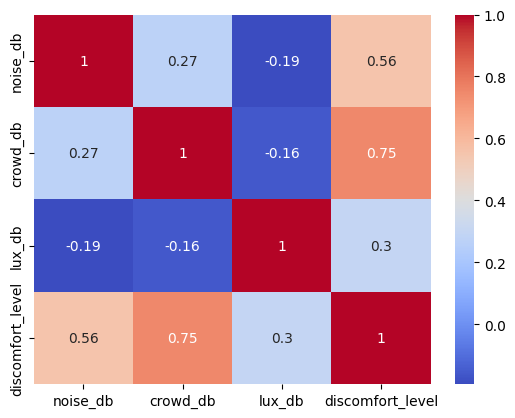

In [38]:
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

**Conclusion:**
There seems to be a high amount of outliers regarding the noisyness and brightness. These outliers, however, are plausible. Looking at the images, some pictures are shot at an empty street and/or at night. This could explain the downward outliers regarding the noise. In case of the brightness, some images were shot in summer and seem to be slightly overexposed to the light, which could explain the upward outliers.

Regarding the distributions, the noise is strongly skewed to the left. This could be result of the settings, which mostly depict public open spaces. The all in all rather low noise-levels could be explained with the security-camera-style data-collection, meaning the recording devices were not directly in the crowd of people but slightly away from them.

## Result

The setting of this dataset does not seem to correspont with the needs of the AURA-project. Where the AURA-project needs highly specific data (e.g. the noise, brightness, and crowdedness in a supermarket), this dataset includes the correct features but only for public open spaces. Adding to this, the data was not directly collected in the middle of the crowd (where a person would be), but from slightly atop.

Another factor that does not correspond with the project needs is the number of people. Since AURA aims to help in different day-to-day situations, the data collection from only open spaces does not reflect situations like shopping groceries, for example.

To add to this, the dataset was created for a different goal, so it did not come with the target variable, which was added in accrodance with the method used to create the synthetic data. The lack of the target variable is a critical factor making supervised learning impossible.

In conclusion, it is not advised to use this dataset for training and evaluating the AURA-model. Instead, if the project should be continued, collection of real world data should be one of the next main objectives.